In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import pandas as pd
import numpy as np




df = pd.read_csv('/content/drive/MyDrive/Metro_Interstate_Traffic_Volume.csv')
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

print("Raw shape:", df.shape)
print("Date range:", df["date_time"].min(), "→", df["date_time"].max())
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

print("Raw shape:", df.shape)
print("Date range:", df["date_time"].min(), "→", df["date_time"].max())

Raw shape: (48204, 9)
Date range: 2012-10-02 09:00:00 → 2018-09-30 23:00:00
Raw shape: (48204, 9)
Date range: 2012-10-02 09:00:00 → 2018-09-30 23:00:00


In [42]:
print(df.columns.tolist())

['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']


In [43]:
dup_mask = df["date_time"].duplicated(keep=False)
dup_rows = df[dup_mask]

agreement_check = dup_rows.groupby("date_time")["traffic_volume"].nunique()
identical = (agreement_check == 1).sum()
conflicting = (agreement_check > 1).sum()

print(f"Duplicate timestamp groups: {len(agreement_check)}")
print(f"  Identical traffic_volume: {identical}")
print(f"  Conflicting traffic_volume: {conflicting}")

if conflicting > 0:
    print("WARNING — inspect before dropping:")
    display(agreement_check[agreement_check > 1])

before_shape = df.shape
df = df.drop_duplicates(subset="date_time", keep="first").reset_index(drop=True)
after_shape = df.shape

print(f"\nShape before dedup: {before_shape}")
print(f"Shape after dedup:  {after_shape}")
print(f"Rows removed: {before_shape[0] - after_shape[0]}")
print(f"Remaining duplicate timestamps: {df['date_time'].duplicated().sum()}")
print(f"Missing traffic_volume: {df['traffic_volume'].isna().sum()}")

Duplicate timestamp groups: 5445
  Identical traffic_volume: 5445
  Conflicting traffic_volume: 0

Shape before dedup: (48204, 9)
Shape after dedup:  (40575, 9)
Rows removed: 7629
Remaining duplicate timestamps: 0
Missing traffic_volume: 0


In [44]:
df["time_diff"] = df["date_time"].diff().dt.total_seconds() / 3600

full_range = pd.date_range(df["date_time"].min(), df["date_time"].max(), freq="h")
n_possible, n_observed = len(full_range), len(df)
n_missing = n_possible - n_observed

print(f"Total possible hourly timestamps: {n_possible}")
print(f"Observed: {n_observed}  |  Missing: {n_missing} ({n_missing/n_possible*100:.2f}%)")

exactly_hourly = (df["time_diff"] == 1.0).sum()
total_intervals = df["time_diff"].notna().sum()
print(f"Exactly 1-hour intervals: {exactly_hourly}/{total_intervals} "
      f"({exactly_hourly/total_intervals*100:.2f}%)")

gaps = df[df["time_diff"] > 1][["date_time", "time_diff"]].copy()
gaps["missing_hours"] = gaps["time_diff"] - 1

def bucket(h):
    if h <= 6: return "1-6h"
    elif h <= 24: return "7-24h"
    elif h <= 168: return "25-168h"
    else: return ">168h"

gaps["bucket"] = gaps["missing_hours"].apply(bucket)
gap_summary = gaps.groupby("bucket").agg(
    n_gaps=("missing_hours", "count"),
    total_missing_hours=("missing_hours", "sum")
).reindex(["1-6h", "7-24h", "25-168h", ">168h"])

print("\nGap distribution:")
display(gap_summary)
print(f"Largest gap: {gaps['missing_hours'].max():.0f}h "
      f"(~{gaps['missing_hours'].max()/24:.1f} days)")

Total possible hourly timestamps: 52551
Observed: 40575  |  Missing: 11976 (22.79%)
Exactly 1-hour intervals: 37986/40574 (93.62%)

Gap distribution:


,n_gaps,total_missing_hours
bucket,,
1-6h,2512,3048.0
7-24h,65,742.0
25-168h,9,558.0
>168h,2,7628.0


Largest gap: 7386h (~307.8 days)


In [45]:
LARGE_GAP_THRESHOLD_HOURS = 24  # matches the threshold already used/verified in this project

df["large_gap_before"] = df["time_diff"] > LARGE_GAP_THRESHOLD_HOURS
df.loc[df.index[0], "large_gap_before"] = False
df["segment_id"] = df["large_gap_before"].cumsum()

n_segments = df["segment_id"].nunique()
n_boundaries = df["large_gap_before"].sum()
print(f"Threshold: >{LARGE_GAP_THRESHOLD_HOURS}h  |  Segments: {n_segments}  |  Boundaries: {n_boundaries}")

seg_summary = df.groupby("segment_id").agg(
    n_obs=("date_time", "count"), start=("date_time", "min"), end=("date_time", "max")
)
seg_summary["pct_of_total"] = (seg_summary["n_obs"] / len(df) * 100).round(1)
display(seg_summary)

Threshold: >24h  |  Segments: 13  |  Boundaries: 12


,n_obs,start,end,pct_of_total
segment_id,,,,
0,2664,2012-10-02 09:00:00,2013-01-29 00:00:00,6.6
1,4675,2013-01-30 01:00:00,2013-08-31 00:00:00,11.5
2,26,2013-09-01 23:00:00,2013-09-03 02:00:00,0.1
3,766,2013-09-04 08:00:00,2013-10-27 01:00:00,1.9
4,4057,2013-11-06 04:00:00,2014-04-29 08:00:00,10.0
5,1549,2014-05-04 05:00:00,2014-07-27 16:00:00,3.8
6,63,2014-07-30 09:00:00,2014-08-02 02:00:00,0.2
7,98,2014-08-03 11:00:00,2014-08-08 01:00:00,0.2
8,7,2015-06-11 20:00:00,2015-06-14 20:00:00,0.0


In [46]:
weather_cols = ["temp", "rain_1h", "snow_1h", "clouds_all", "weather_main", "weather_description"]
df[weather_cols] = df.groupby("segment_id")[weather_cols].ffill()
df["holiday"] = df["holiday"].fillna("None")
print("Missing weather values after within-segment fill:")
print(df[weather_cols].isna().sum())

Missing weather values after within-segment fill:
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
dtype: int64


--- EXPLORATORY DATA ANALYSIS ---


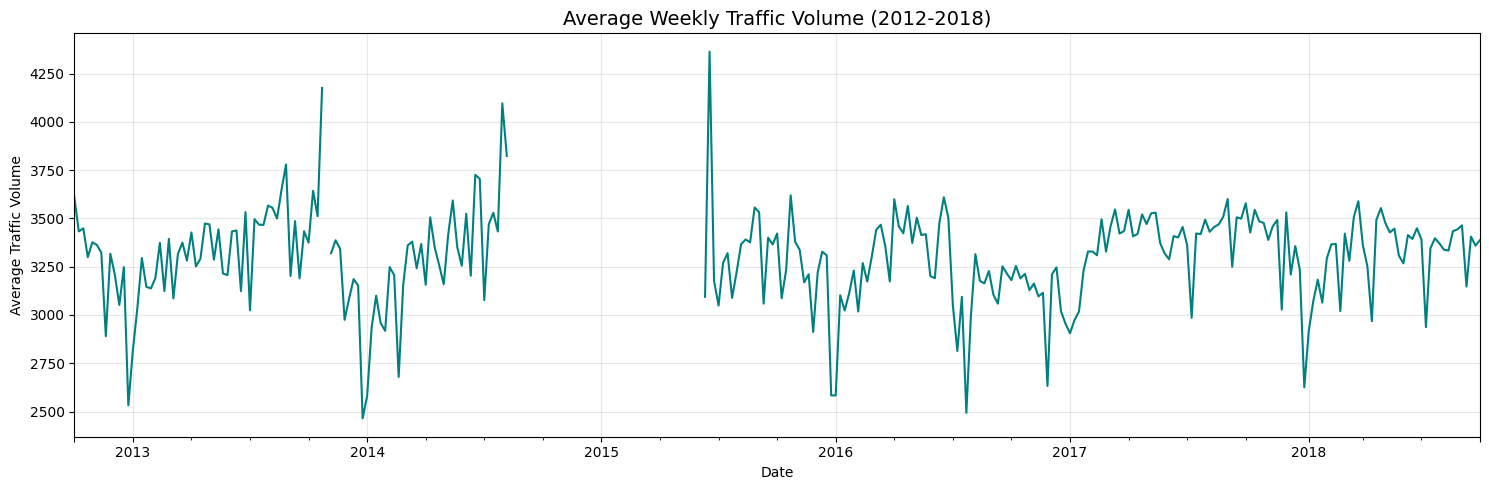

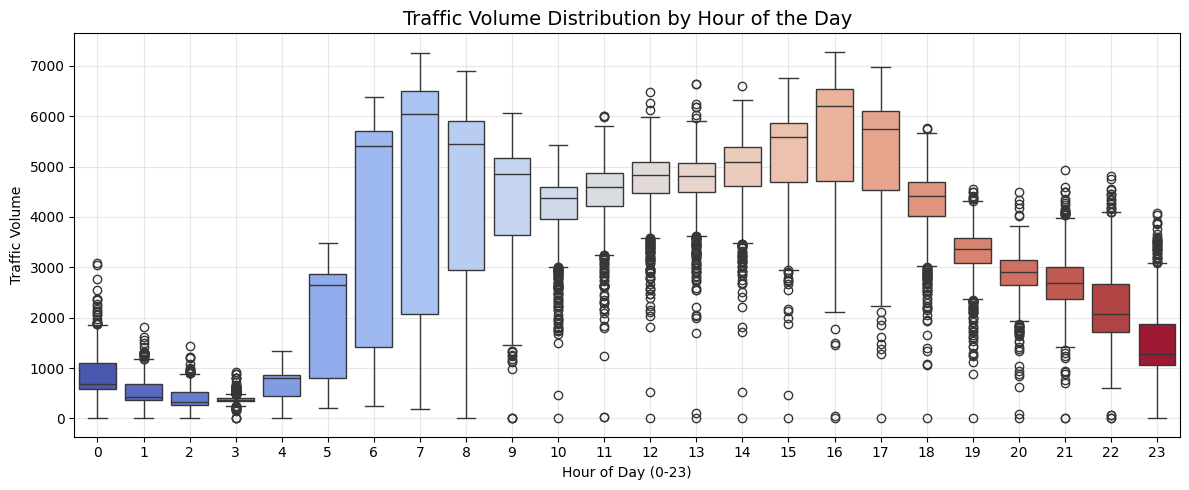

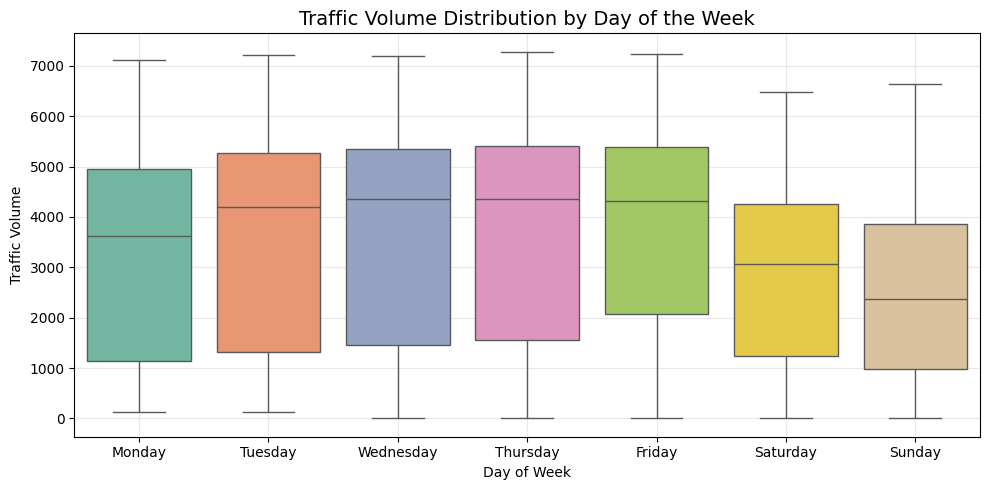

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EXPLORATORY DATA ANALYSIS ---")

# 1. Overall Traffic Volume Over Time (resampled weekly to smooth the noise)
plt.figure(figsize=(15, 5))
df.set_index('date_time')['traffic_volume'].resample('W').mean().plot(color='teal', linewidth=1.5)
plt.title('Average Weekly Traffic Volume (2012-2018)', fontsize=14)
plt.ylabel('Average Traffic Volume')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Seasonality: Traffic by Hour of the Day
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['date_time'].dt.hour, y=df['traffic_volume'], palette='coolwarm', hue=df['date_time'].dt.hour, legend=False)
plt.title('Traffic Volume Distribution by Hour of the Day', fontsize=14)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Traffic Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Seasonality: Traffic by Day of the Week
plt.figure(figsize=(10, 5))
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x=df['date_time'].dt.dayofweek, y=df['traffic_volume'], palette='Set2', hue=df['date_time'].dt.dayofweek, legend=False)
plt.title('Traffic Volume Distribution by Day of the Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Traffic Volume')
plt.xticks(ticks=range(7), labels=days)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
df_features = df.sort_values(['segment_id', 'date_time']).reset_index(drop=True)

# Calendar + cyclical
df_features['hour'] = df_features['date_time'].dt.hour
df_features['day_of_week'] = df_features['date_time'].dt.dayofweek
df_features['month'] = df_features['date_time'].dt.month
df_features['is_weekend'] = (df_features['day_of_week'] >= 5).astype(int)
df_features['hour_sin'] = np.sin(2*np.pi*df_features['hour']/24)
df_features['hour_cos'] = np.cos(2*np.pi*df_features['hour']/24)
df_features['dow_sin'] = np.sin(2*np.pi*df_features['day_of_week']/7)
df_features['dow_cos'] = np.cos(2*np.pi*df_features['day_of_week']/7)
df_features['is_holiday'] = (df_features['holiday'] != 'None').astype(int)

# Lags — grouped by segment_id, never cross a large gap
g = df_features.groupby('segment_id')['traffic_volume']
df_features['lag_1'] = g.shift(1)
df_features['lag_24'] = g.shift(24)
df_features['lag_168'] = g.shift(168)

# Rolling — shift(1) first, then roll, within segment
grouped = df_features.groupby('segment_id')['traffic_volume']
df_features['rolling_mean_3h'] = grouped.transform(lambda x: x.shift(1).rolling(3).mean())
df_features['rolling_std_3h']  = grouped.transform(lambda x: x.shift(1).rolling(3).std())
df_features['rolling_mean_24h']= grouped.transform(lambda x: x.shift(1).rolling(24).mean())
df_features['rolling_std_24h'] = grouped.transform(lambda x: x.shift(1).rolling(24).std())

print("Feature shape:", df_features.shape)

Feature shape: (40575, 28)


In [49]:
df_model = df_features.sort_values('date_time').reset_index(drop=True)
n = len(df_model)
train_end, val_end = int(n*0.70), int(n*0.85)

train_df = df_model.iloc[:train_end].copy()
val_df   = df_model.iloc[train_end:val_end].copy()
test_df  = df_model.iloc[val_end:].copy()

for name, d in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    print(f"{name}: {len(d)} rows, {d['date_time'].min()} → {d['date_time'].max()}")

TRAIN: 28402 rows, 2012-10-02 09:00:00 → 2017-05-10 04:00:00
VAL: 6086 rows, 2017-05-10 05:00:00 → 2018-01-19 14:00:00
TEST: 6087 rows, 2018-01-19 15:00:00 → 2018-09-30 23:00:00


In [50]:
def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    return float(np.mean(2*np.abs(y_true[mask]-y_pred[mask])/denom[mask]) * 100)

def compute_mase_denominator(train_data, seasonal_period=168):
    """Segment+time aware: merge each row with its actual value exactly
    `seasonal_period` hours earlier, matched within the same segment_id."""
    base = train_data[['date_time', 'segment_id', 'traffic_volume']].copy()
    prior = base.rename(columns={'date_time': 'previous_date_time',
                                  'traffic_volume': 'previous_traffic'})
    base['previous_date_time'] = base['date_time'] - pd.Timedelta(hours=seasonal_period)
    pairs = base.merge(prior, on=['segment_id', 'previous_date_time'], how='inner')
    errors = (pairs['traffic_volume'] - pairs['previous_traffic']).abs()
    return float(errors.mean()), len(errors)

mase_denom_trainval, n_pairs = compute_mase_denominator(train_df)
print(f"MASE denominator (train only): {mase_denom_trainval:.4f}  ({n_pairs} pairs)")

mase_denom_final, n_pairs_final = compute_mase_denominator(pd.concat([train_df, val_df]))
print(f"MASE denominator (train+val, for final test): {mase_denom_final:.4f}  ({n_pairs_final} pairs)")

MASE denominator (train only): 340.6201  (25055 pairs)
MASE denominator (train+val, for final test): 338.8887  (31123 pairs)


In [51]:
HORIZONS = [1, 3, 6, 12, 24]

def seasonal_naive_eval(data, denominator, seasonal_period=168):
    base = data[['date_time', 'traffic_volume', 'segment_id']].copy().sort_values('date_time')
    results = []
    for h in HORIZONS:
        base['target_time'] = base['date_time'] + pd.Timedelta(hours=h)
        base['reference_time'] = base['target_time'] - pd.Timedelta(hours=seasonal_period)

        future = base[['date_time','traffic_volume','segment_id']].rename(
            columns={'date_time':'target_time','traffic_volume':'actual'})
        seasonal = base[['date_time','traffic_volume','segment_id']].rename(
            columns={'date_time':'reference_time','traffic_volume':'prediction'})

        ev = base[['date_time','target_time','reference_time','segment_id']] \
            .merge(future, on=['target_time','segment_id'], how='left') \
            .merge(seasonal, on=['reference_time','segment_id'], how='left') \
            .dropna(subset=['actual','prediction'])

        mae = np.mean(np.abs(ev['actual'] - ev['prediction']))
        s = smape(ev['actual'], ev['prediction'])
        m = mae / denominator
        results.append({'horizon_hours': h, 'observations': len(ev), 'MAE': mae, 'sMAPE': s, 'MASE': m})
    return pd.DataFrame(results)

naive_final = seasonal_naive_eval(test_df, mase_denom_final)
print("Seasonal Naive — FINAL TEST")
display(naive_final.round(4))

Seasonal Naive — FINAL TEST


,horizon_hours,observations,MAE,sMAPE,MASE
0,1,5890,318.6117,11.6769,0.9402
1,3,5886,318.4985,11.6830,0.9398
2,6,5883,318.1696,11.6833,0.9389
3,12,5883,318.1722,11.6845,0.9389
4,24,5885,318.6929,11.6681,0.9404


In [52]:
HORIZONS = [1, 3, 6, 12, 24]

def seasonal_naive_eval(data, denominator, seasonal_period=168):
    base = data[['date_time', 'traffic_volume', 'segment_id']].copy().sort_values('date_time')
    results = []
    for h in HORIZONS:
        base['target_time'] = base['date_time'] + pd.Timedelta(hours=h)
        base['reference_time'] = base['target_time'] - pd.Timedelta(hours=seasonal_period)

        future = base[['date_time','traffic_volume','segment_id']].rename(
            columns={'date_time':'target_time','traffic_volume':'actual'})
        seasonal = base[['date_time','traffic_volume','segment_id']].rename(
            columns={'date_time':'reference_time','traffic_volume':'prediction'})

        ev = base[['date_time','target_time','reference_time','segment_id']] \
            .merge(future, on=['target_time','segment_id'], how='left') \
            .merge(seasonal, on=['reference_time','segment_id'], how='left') \
            .dropna(subset=['actual','prediction'])

        mae = np.mean(np.abs(ev['actual'] - ev['prediction']))
        s = smape(ev['actual'], ev['prediction'])
        m = mae / denominator
        results.append({'horizon_hours': h, 'observations': len(ev), 'MAE': mae, 'sMAPE': s, 'MASE': m})
    return pd.DataFrame(results)

naive_final = seasonal_naive_eval(test_df, mase_denom_final)
print("Seasonal Naive — FINAL TEST")
display(naive_final.round(4))

Seasonal Naive — FINAL TEST


,horizon_hours,observations,MAE,sMAPE,MASE
0,1,5890,318.6117,11.6769,0.9402
1,3,5886,318.4985,11.6830,0.9398
2,6,5883,318.1696,11.6833,0.9389
3,12,5883,318.1722,11.6845,0.9389
4,24,5885,318.6929,11.6681,0.9404


In [53]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

feature_cols = ["temp","rain_1h","snow_1h","clouds_all","hour","day_of_week","month",
                 "is_weekend","hour_sin","hour_cos","dow_sin","dow_cos","is_holiday",
                 "lag_1","lag_24","lag_168","rolling_mean_3h","rolling_std_3h",
                 "rolling_mean_24h","rolling_std_24h"]

def build_horizon_target(data, h):
    d = data.copy()
    d["future_target"] = d.groupby("segment_id")["traffic_volume"].shift(-h)
    return d.dropna(subset=feature_cols + ["future_target"])

def run_xgb_horizon(train_data, eval_data, denominator):
    results, models, preds_by_h = [], {}, {}
    for h in HORIZONS:
        tr = build_horizon_target(train_data, h)
        ev = build_horizon_target(eval_data, h)
        X_train, y_train = tr[feature_cols], tr["future_target"]
        X_eval, y_eval = ev[feature_cols], ev["future_target"]

        model = XGBRegressor(n_estimators=500, max_depth=8, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              objective="reg:squarederror", random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        preds = model.predict(X_eval)

        mae = np.mean(np.abs(y_eval.values - preds))
        s = smape(y_eval.values, preds)
        m = mae / denominator
        results.append({"horizon_hours": h, "observations": len(y_eval), "MAE": mae, "sMAPE": s, "MASE": m})
        models[h] = model
        preds_by_h[h] = {"date_time": ev["date_time"].values, "actual": y_eval.values, "predicted": preds}
    return pd.DataFrame(results), models, preds_by_h

print("XGBoost — EXPANDING WINDOW CROSS-VALIDATION")

# Combine train and val so we can split them dynamically.
train_val_df = pd.concat([train_df, val_df], ignore_index=True).sort_values("date_time").reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=3)
fold = 1
cv_results = []

for train_index, val_index in tscv.split(train_val_df):
    cv_train = train_val_df.iloc[train_index].copy()
    cv_val = train_val_df.iloc[val_index].copy()

    print(f"--- FOLD {fold} ---")

    # Calculate a fold-specific MASE denominator
    fold_mase_denom, _ = compute_mase_denominator(cv_train)

    # Run XGBoost for this fold
    fold_results, _, _ = run_xgb_horizon(cv_train, cv_val, fold_mase_denom)
    fold_results['Fold'] = fold
    cv_results.append(fold_results)
    fold += 1

# Average the results across all folds
all_cv_results = pd.concat(cv_results)
avg_cv_results = all_cv_results.groupby('horizon_hours')[['MAE', 'sMAPE', 'MASE']].mean().reset_index()
print("\nAverage Validation Metrics:")
display(avg_cv_results.round(4))

# Final test stage (train+val -> test)
final_train_df = pd.concat([train_df, val_df], ignore_index=True).sort_values("date_time").reset_index(drop=True)
xgb_test_results, xgb_test_models, xgb_test_predictions = run_xgb_horizon(final_train_df, test_df, mase_denom_final)

print("\nXGBoost — FINAL TEST")
display(xgb_test_results.round(4))

XGBoost — EXPANDING WINDOW CROSS-VALIDATION
--- FOLD 1 ---
--- FOLD 2 ---
--- FOLD 3 ---

Average Validation Metrics:


,horizon_hours,MAE,sMAPE,MASE
0,1,262.9718,11.9050,0.7703
1,3,371.9076,16.9616,1.0900
2,6,467.6198,21.7010,1.3715
3,12,632.7272,28.0154,1.8572
4,24,763.4841,33.1181,2.2395



XGBoost — FINAL TEST


,horizon_hours,observations,MAE,sMAPE,MASE
0,1,6086,176.1365,7.4493,0.5197
1,3,6084,216.5343,9.4532,0.6390
2,6,6081,246.7107,11.2880,0.7280
3,12,6075,295.1253,13.9565,0.8709
4,24,6063,351.7814,16.6423,1.0380


In [54]:
from prophet import Prophet

# Define the extra covariates Prophet will use
prophet_regressors = ["temp", "rain_1h", "snow_1h", "clouds_all", "is_weekend", "is_holiday"]

def train_prophet(data):
    # Include regressors in the prepared dataframe
    cols_to_keep = ["date_time", "traffic_volume"] + prophet_regressors
    p = data[cols_to_keep].rename(columns={"date_time": "ds", "traffic_volume": "y"}).dropna()

    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)

    # Add each regressor BEFORE fitting the model
    for reg in prophet_regressors:
        m.add_regressor(reg)

    m.fit(p)
    return m

def prophet_eval(model, eval_data, denominator):
    # The future dataframe MUST include the exact same regressors used in training
    cols_to_keep = ["date_time"] + prophet_regressors
    future = eval_data[cols_to_keep].rename(columns={"date_time": "ds"}).drop_duplicates()

    # Generate predictions
    forecast = model.predict(future)[["ds", "yhat"]]

    # Merge predictions with actuals
    merged = eval_data[["date_time", "traffic_volume"]].rename(columns={"date_time": "ds", "traffic_volume": "actual"}) \
        .merge(forecast, on="ds", how="inner").sort_values("ds").reset_index(drop=True)

    results = []
    for h in HORIZONS:
        d = merged.iloc[h-1:]
        mae = np.mean(np.abs(d["actual"] - d["yhat"]))
        s = smape(d["actual"], d["yhat"])
        m = mae / denominator
        results.append({"horizon_hours": h, "observations": len(d), "MAE": mae, "sMAPE": s, "MASE": m})
    return pd.DataFrame(results)

# Validation stage
prophet_model_val = train_prophet(train_df)
prophet_val_results = prophet_eval(prophet_model_val, val_df, mase_denom_trainval)
print("Prophet — VALIDATION WITH REGRESSORS"); display(prophet_val_results.round(4))

# Final test stage
prophet_model_final = train_prophet(final_train_df)
prophet_test_results = prophet_eval(prophet_model_final, test_df, mase_denom_final)
print("\nProphet — FINAL TEST WITH REGRESSORS"); display(prophet_test_results.round(4))

Prophet — VALIDATION WITH REGRESSORS


,horizon_hours,observations,MAE,sMAPE,MASE
0,1,6086,688.9393,35.2116,2.0226
1,3,6084,688.8640,35.2170,2.0224
2,6,6081,688.8365,35.2281,2.0223
3,12,6075,689.1896,35.2566,2.0233
4,24,6063,689.4379,35.2465,2.0241



Prophet — FINAL TEST WITH REGRESSORS


,horizon_hours,observations,MAE,sMAPE,MASE
0,1,6087,612.0733,32.6822,1.8061
1,3,6085,612.1979,32.6917,1.8065
2,6,6082,612.3313,32.7038,1.8069
3,12,6076,612.5248,32.6926,1.8075
4,24,6064,611.8561,32.6236,1.8055


In [55]:
final_comparison = pd.DataFrame({"horizon_hours": HORIZONS})
final_comparison["Naive_MAE"], final_comparison["Naive_sMAPE"], final_comparison["Naive_MASE"] = \
    naive_final["MAE"].values, naive_final["sMAPE"].values, naive_final["MASE"].values
final_comparison["Prophet_MAE"], final_comparison["Prophet_sMAPE"], final_comparison["Prophet_MASE"] = \
    prophet_test_results["MAE"].values, prophet_test_results["sMAPE"].values, prophet_test_results["MASE"].values
final_comparison["XGBoost_MAE"], final_comparison["XGBoost_sMAPE"], final_comparison["XGBoost_MASE"] = \
    xgb_test_results["MAE"].values, xgb_test_results["sMAPE"].values, xgb_test_results["MASE"].values

print("FINAL COMPARISON — Naive vs Prophet vs XGBoost, same test set")
display(final_comparison.round(4))

FINAL COMPARISON — Naive vs Prophet vs XGBoost, same test set


,horizon_hours,Naive_MAE,Naive_sMAPE,Naive_MASE,Prophet_MAE,Prophet_sMAPE,Prophet_MASE,XGBoost_MAE,XGBoost_sMAPE,XGBoost_MASE
0,1,318.6117,11.6769,0.9402,612.0733,32.6822,1.8061,176.1365,7.4493,0.5197
1,3,318.4985,11.6830,0.9398,612.1979,32.6917,1.8065,216.5343,9.4532,0.6390
2,6,318.1696,11.6833,0.9389,612.3313,32.7038,1.8069,246.7107,11.2880,0.7280
3,12,318.1722,11.6845,0.9389,612.5248,32.6926,1.8075,295.1253,13.9565,0.8709
4,24,318.6929,11.6681,0.9404,611.8561,32.6236,1.8055,351.7814,16.6423,1.0380


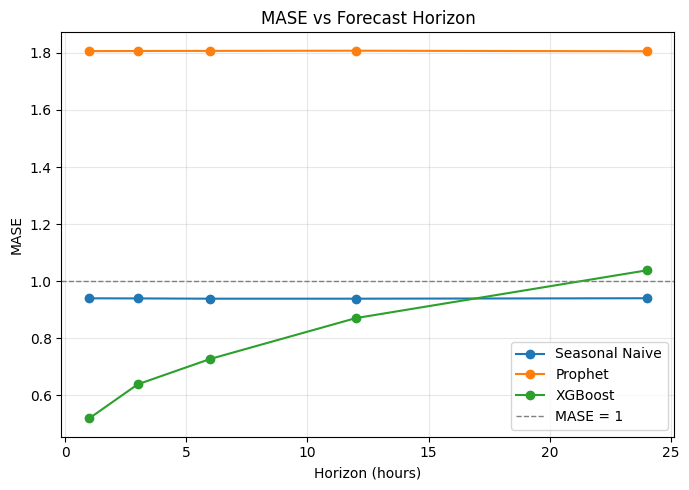

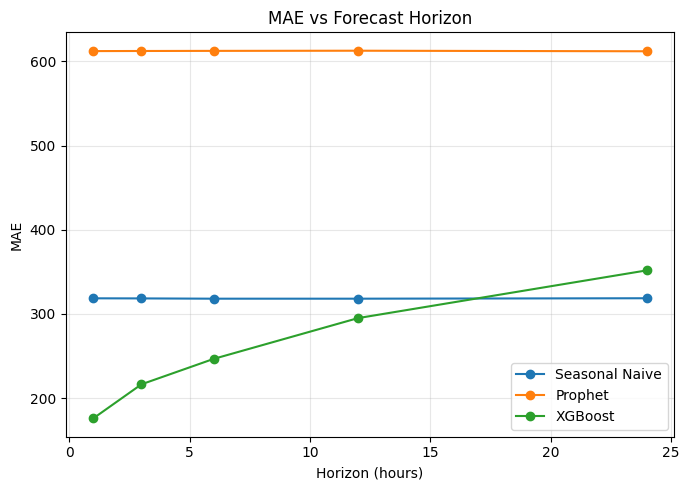

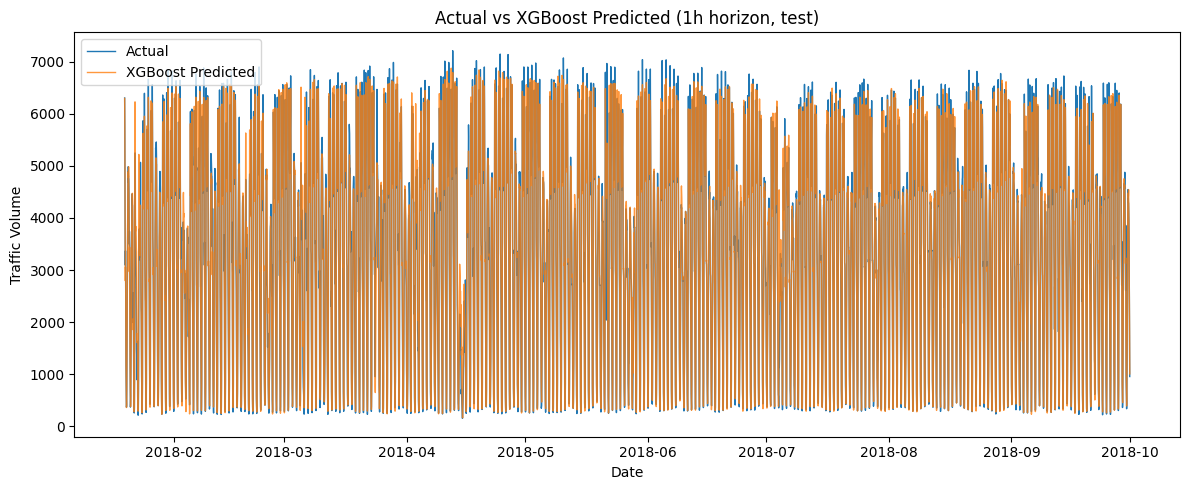

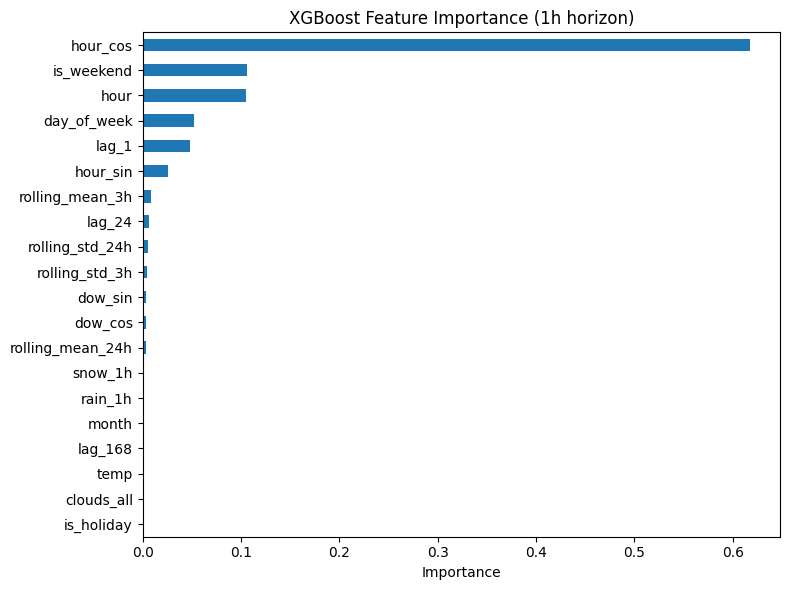

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(final_comparison["horizon_hours"], final_comparison["Naive_MASE"], marker='o', label="Seasonal Naive")
plt.plot(final_comparison["horizon_hours"], final_comparison["Prophet_MASE"], marker='o', label="Prophet")
plt.plot(final_comparison["horizon_hours"], final_comparison["XGBoost_MASE"], marker='o', label="XGBoost")
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1, label="MASE = 1")
plt.xlabel("Horizon (hours)"); plt.ylabel("MASE"); plt.title("MASE vs Forecast Horizon")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(final_comparison["horizon_hours"], final_comparison["Naive_MAE"], marker='o', label="Seasonal Naive")
plt.plot(final_comparison["horizon_hours"], final_comparison["Prophet_MAE"], marker='o', label="Prophet")
plt.plot(final_comparison["horizon_hours"], final_comparison["XGBoost_MAE"], marker='o', label="XGBoost")
plt.xlabel("Horizon (hours)"); plt.ylabel("MAE"); plt.title("MAE vs Forecast Horizon")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

p = xgb_test_predictions[1]
plt.figure(figsize=(12,5))
plt.plot(p["date_time"], p["actual"], label="Actual", linewidth=1)
plt.plot(p["date_time"], p["predicted"], label="XGBoost Predicted", linewidth=1, alpha=0.8)
plt.xlabel("Date"); plt.ylabel("Traffic Volume"); plt.title("Actual vs XGBoost Predicted (1h horizon, test)")
plt.legend(); plt.tight_layout(); plt.show()

importance = pd.Series(xgb_test_models[1].feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importance.plot(kind='barh'); plt.gca().invert_yaxis()
plt.xlabel("Importance"); plt.title("XGBoost Feature Importance (1h horizon)")
plt.tight_layout(); plt.show()

In [57]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (22707, 20)
y_train shape: (27942, 5)


In [58]:
from sklearn.preprocessing import StandardScaler
import numpy as np

SEQ_LEN = 24
HORIZONS = [1, 3, 6, 12, 24]
MAX_HORIZON = max(HORIZONS)

lstm_features = ["traffic_volume", "temp", "rain_1h", "snow_1h", "clouds_all",
                  "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_holiday"]

scaler = StandardScaler()
scaler.fit(train_df[lstm_features])

def make_sequences_multi_horizon(data, seq_len=SEQ_LEN, horizons=HORIZONS):
    all_X, all_y, all_dates = [], [], []
    max_h = max(horizons)

    for seg_id, seg_df in data.groupby("segment_id"):
        seg_df = seg_df.sort_values("date_time").reset_index(drop=True)
        if len(seg_df) < seq_len + max_h:
            continue

        scaled = scaler.transform(seg_df[lstm_features])
        traffic = seg_df["traffic_volume"].values
        dates = seg_df["date_time"].values

        for i in range(len(seg_df) - seq_len - max_h + 1):
            window_end = i + seq_len
            targets = [traffic[window_end + h - 1] for h in horizons]
            if any(np.isnan(t) for t in targets):
                continue
            all_X.append(scaled[i:window_end])
            all_y.append(targets)
            all_dates.append(dates[window_end - 1])

    return np.array(all_X), np.array(all_y), np.array(all_dates)

X_train, y_train, _ = make_sequences_multi_horizon(train_df)
X_val, y_val, _ = make_sequences_multi_horizon(val_df)

final_train_df = pd.concat([train_df, val_df], ignore_index=True)
X_train_final, y_train_final, _ = make_sequences_multi_horizon(final_train_df)
X_test, y_test, test_dates = make_sequences_multi_horizon(test_df)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (27942, 24, 10)
y_train shape: (27942, 5)


In [59]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_lstm_model(seq_len, n_features, n_horizons):
    inputs = Input(shape=(seq_len, n_features))
    x = LSTM(64, return_sequences=False)(inputs)
    x = Dropout(0.2)(x)
    x = Dense(32, activation="relu")(x)
    outputs = Dense(n_horizons)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mae")
    return model

lstm_model = build_lstm_model(SEQ_LEN, len(lstm_features), len(HORIZONS))

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 3083.2534 - val_loss: 2869.3821
Epoch 2/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 2460.0469 - val_loss: 2228.0063
Epoch 3/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 1933.3475 - val_loss: 1721.5089
Epoch 4/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1589.7183 - val_loss: 1380.0208
Epoch 5/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 1401.9393 - val_loss: 1236.0513
Epoch 6/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1293.8168 - val_loss: 1126.7278
Epoch 7/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 1204.1172 - val_loss: 1034.4105
Epoch 8/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 1120.0341 - val_loss: 915.8379
Epoch 9/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 1041.1738 - val_loss: 832.2264
Epoch 10/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 985.1217 - val_loss: 771.4519
Epoch 11/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 936.3883 -

In [ ]:
# Retrain on train+val for the final test evaluation, matching XGBoost/Prophet's protocol
lstm_final_model = build_lstm_model(SEQ_LEN, len(lstm_features), len(HORIZONS))
lstm_final_model.fit(X_train_final, y_train_final, epochs=len(history.history["loss"]),
                      batch_size=64, verbose=1)

lstm_preds = lstm_final_model.predict(X_test)  # shape: (n_samples, 5)

lstm_results = []
for i, h in enumerate(HORIZONS):
    y_true_h = y_test[:, i]
    y_pred_h = lstm_preds[:, i]
    mae = np.mean(np.abs(y_true_h - y_pred_h))
    s = smape(y_true_h, y_pred_h)
    m = mae / mase_denom_final
    lstm_results.append({"horizon_hours": h, "observations": len(y_true_h),
                          "MAE": mae, "sMAPE": s, "MASE": m})

lstm_results = pd.DataFrame(lstm_results)
print("LSTM — FINAL TEST, all horizons")
display(lstm_results.round(4))

Epoch 1/50
532/532 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 2966.3167
Epoch 2/50
532/532 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 2099.4021
Epoch 3/50
532/532 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 1642.9281
Epoch 4/50
  8/532 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 1524.1654

In [ ]:
final_comparison["LSTM_MAE"]   = lstm_results["MAE"].values
final_comparison["LSTM_sMAPE"] = lstm_results["sMAPE"].values
final_comparison["LSTM_MASE"]  = lstm_results["MASE"].values

print("FINAL COMPARISON — Naive vs Prophet vs XGBoost vs LSTM")
display(final_comparison.round(4))


In [ ]:
plt.figure(figsize=(7,5))
for col, label in [("Naive_MASE","Seasonal Naive"), ("Prophet_MASE","Prophet"),
                    ("XGBoost_MASE","XGBoost"), ("LSTM_MASE","LSTM")]:
    plt.plot(final_comparison["horizon_hours"], final_comparison[col], marker='o', label=label)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1, label="MASE = 1")
plt.xlabel("Forecast horizon (hours)"); plt.ylabel("MASE"); plt.title("MASE vs Forecast Horizon — All Models")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
for col, label in [("Naive_MASE","Seasonal Naive"), ("Prophet_MASE","Prophet"),
                    ("XGBoost_MASE","XGBoost"), ("LSTM_MASE","LSTM")]:
    plt.plot(final_comparison["horizon_hours"], final_comparison[col], marker='o', label=label)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1, label="MASE = 1")
plt.xlabel("Horizon (hours)"); plt.ylabel("MASE"); plt.title("MASE vs Forecast Horizon — All Models")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
for col, label in [("Naive_MAE","Seasonal Naive"), ("Prophet_MAE","Prophet"),
                    ("XGBoost_MAE","XGBoost"), ("LSTM_MAE","LSTM")]:
    plt.plot(final_comparison["horizon_hours"], final_comparison[col], marker='o', label=label)
plt.xlabel("Horizon (hours)"); plt.ylabel("MAE"); plt.title("MAE vs Forecast Horizon — All Models")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

p = xgb_test_predictions[1]
plt.figure(figsize=(12,5))
plt.plot(p["date_time"], p["actual"], label="Actual", linewidth=1)
plt.plot(p["date_time"], p["predicted"], label="XGBoost Predicted", linewidth=1, alpha=0.8)
plt.xlabel("Date"); plt.ylabel("Traffic Volume"); plt.title("Actual vs XGBoost Predicted (1h horizon, test)")
plt.legend(); plt.tight_layout(); plt.show()

importance = pd.Series(xgb_test_models[1].feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importance.plot(kind='barh'); plt.gca().invert_yaxis()
plt.xlabel("Importance"); plt.title("XGBoost Feature Importance (1h horizon)")
plt.tight_layout(); plt.show()